In [2]:
# ============================================================
# DYNAMIC PRICING INTELLIGENCE SYSTEM
# MACHINE LEARNING
# ============================================================

import os
import warnings
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

warnings.filterwarnings("ignore")

print("✅ All libraries imported successfully")

✅ All libraries imported successfully


In [3]:
# ============================================================
# 1. LOAD PROCESSED DATASET
# ============================================================

DATA_PATH = r"C:\Users\ANTARA\OneDrive\Documents\Career\Dynamic Pricing Intelligence System\pricing_data_processed.csv"

pricing_df = pd.read_csv(DATA_PATH)

print("✅ Dataset loaded successfully")
print()
print("Dataset shape:", pricing_df.shape)
print()
print("Columns:")
print(list(pricing_df.columns))

✅ Dataset loaded successfully

Dataset shape: (1017209, 18)

Columns:
['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo', 'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment', 'CompetitionDistance', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval']


In [4]:
# ============================================================
# 2. BASIC DATA INSPECTION
# ============================================================

print("First 5 rows:")
display(pricing_df.head())

print("\nData types:")
print(pricing_df.dtypes)

print("\nDataset information:")
pricing_df.info()

First 5 rows:


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,2,0,1270.0,9.0,2008.0,0,0.0,0.0,3
1,2,5,2015-07-31,6064,625,1,1,0,1,0,0,570.0,11.0,2007.0,1,13.0,2010.0,1
2,3,5,2015-07-31,8314,821,1,1,0,1,0,0,14130.0,12.0,2006.0,1,14.0,2011.0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1,2,2,620.0,9.0,2009.0,0,0.0,0.0,3
4,5,5,2015-07-31,4822,559,1,1,0,1,0,0,29910.0,4.0,2015.0,0,0.0,0.0,3



Data types:
Store                          int64
DayOfWeek                      int64
Date                          object
Sales                          int64
Customers                      int64
Open                           int64
Promo                          int64
StateHoliday                   int64
SchoolHoliday                  int64
StoreType                      int64
Assortment                     int64
CompetitionDistance          float64
CompetitionOpenSinceMonth    float64
CompetitionOpenSinceYear     float64
Promo2                         int64
Promo2SinceWeek              float64
Promo2SinceYear              float64
PromoInterval                  int64
dtype: object

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 18 columns):
 #   Column                     Non-Null Count    Dtype  
---  ------                     --------------    -----  
 0   Store                      1017209 non-null  int64 

In [5]:
# ============================================================
# 3. CHECK MISSING VALUES
# ============================================================

missing_values = pricing_df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

print("\nTotal missing values:", missing_values.sum())

Missing values in each column:
Store                        0
DayOfWeek                    0
Date                         0
Sales                        0
Customers                    0
Open                         0
Promo                        0
StateHoliday                 0
SchoolHoliday                0
StoreType                    0
Assortment                   0
CompetitionDistance          0
CompetitionOpenSinceMonth    0
CompetitionOpenSinceYear     0
Promo2                       0
Promo2SinceWeek              0
Promo2SinceYear              0
PromoInterval                0
dtype: int64

Total missing values: 0


In [6]:
# ============================================================
# 4. CREATE FEATURES AND TARGET
# ============================================================

# Target variable
y = pricing_df["Sales"]

# Features
X = pricing_df.drop(columns=["Sales", "Date"])

print("✅ Features and target created")
print()
print("X shape:", X.shape)
print("y shape:", y.shape)
print()
print("Feature columns:")
print(list(X.columns))

✅ Features and target created

X shape: (1017209, 16)
y shape: (1017209,)

Feature columns:
['Store', 'DayOfWeek', 'Customers', 'Open', 'Promo', 'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment', 'CompetitionDistance', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval']


In [7]:
# ============================================================
# 5. TRAIN-TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("✅ Train-test split completed")
print()
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

✅ Train-test split completed

X_train shape: (813767, 16)
X_test shape: (203442, 16)
y_train shape: (813767,)
y_test shape: (203442,)


In [8]:
# ============================================================
# 6. FEATURE SCALING
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Feature scaling completed")
print()
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

✅ Feature scaling completed

X_train_scaled shape: (813767, 16)
X_test_scaled shape: (203442, 16)


In [9]:
# ============================================================
# 7. TRAIN LINEAR REGRESSION
# ============================================================

linear_model = LinearRegression()

linear_model.fit(
    X_train_scaled,
    y_train
)

print("✅ Linear Regression model trained successfully")

✅ Linear Regression model trained successfully


In [10]:
# ============================================================
# 8. EVALUATE LINEAR REGRESSION
# ============================================================

y_pred_linear = linear_model.predict(X_test_scaled)

mae_linear = mean_absolute_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear))
r2_linear = r2_score(y_test, y_pred_linear)

print("📊 Linear Regression Performance")
print("--------------------------------")
print("MAE :", mae_linear)
print("RMSE:", rmse_linear)
print("R²  :", r2_linear)

📊 Linear Regression Performance
--------------------------------
MAE : 948.7770987776382
RMSE: 1407.8585067280144
R²  : 0.8659751914945784


In [12]:
# ============================================================
# 9. TRAIN DECISION TREE REGRESSOR
# ============================================================

decision_tree = DecisionTreeRegressor(
    max_depth=15,
    random_state=42
)

decision_tree.fit(
    X_train,
    y_train
)

print("✅ Decision Tree model trained successfully")

✅ Decision Tree model trained successfully


In [13]:
# ============================================================
# 10. EVALUATE DECISION TREE
# ============================================================

y_pred_tree = decision_tree.predict(X_test)

mae_tree = mean_absolute_error(y_test, y_pred_tree)
rmse_tree = np.sqrt(mean_squared_error(y_test, y_pred_tree))
r2_tree = r2_score(y_test, y_pred_tree)

print("📊 Decision Tree Performance")
print("--------------------------------")
print("MAE :", mae_tree)
print("RMSE:", rmse_tree)
print("R²  :", r2_tree)

📊 Decision Tree Performance
--------------------------------
MAE : 444.6562172185706
RMSE: 717.9058591961574
R²  : 0.9651500489507738


In [14]:
# ============================================================
# 11. TRAIN RANDOM FOREST REGRESSOR
# ============================================================

# Use a sample to keep memory and training time manageable
X_rf = X_train.sample(
    n=200000,
    random_state=42
)

y_rf = y_train.loc[X_rf.index]

random_forest = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

random_forest.fit(
    X_rf,
    y_rf
)

print("✅ Random Forest model trained successfully")

✅ Random Forest model trained successfully


In [15]:
# ============================================================
# 12. EVALUATE RANDOM FOREST
# ============================================================

y_pred_rf = random_forest.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("📊 Random Forest Performance")
print("--------------------------------")
print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R²  :", r2_rf)

📊 Random Forest Performance
--------------------------------
MAE : 404.95431763868316
RMSE: 650.8802188792394
R²  : 0.9713536480993051


In [16]:
# ============================================================
# 13. MODEL COMPARISON
# ============================================================

model_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "MAE": [
        mae_linear,
        mae_tree,
        mae_rf
    ],
    "RMSE": [
        rmse_linear,
        rmse_tree,
        rmse_rf
    ],
    "R2": [
        r2_linear,
        r2_tree,
        r2_rf
    ]
})

model_comparison = model_comparison.sort_values(
    by="R2",
    ascending=False
).reset_index(drop=True)

display(model_comparison)

,Model,MAE,RMSE,R2
0,Random Forest,404.954318,650.880219,0.971354
1,Decision Tree,444.656217,717.905859,0.965150
2,Linear Regression,948.777099,1407.858507,0.865975


In [17]:
# ============================================================
# 14. FEATURE IMPORTANCE
# ============================================================

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": random_forest.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

display(feature_importance)

,Feature,Importance
0,Customers,0.879110
1,StoreType,0.032881
2,CompetitionDistance,0.024645
3,Promo,0.018297
4,Store,0.012978
5,Assortment,0.006320
6,Promo2SinceWeek,0.005962
7,DayOfWeek,0.004928
8,CompetitionOpenSinceYear,0.004875
9,CompetitionOpenSinceMonth,0.004120


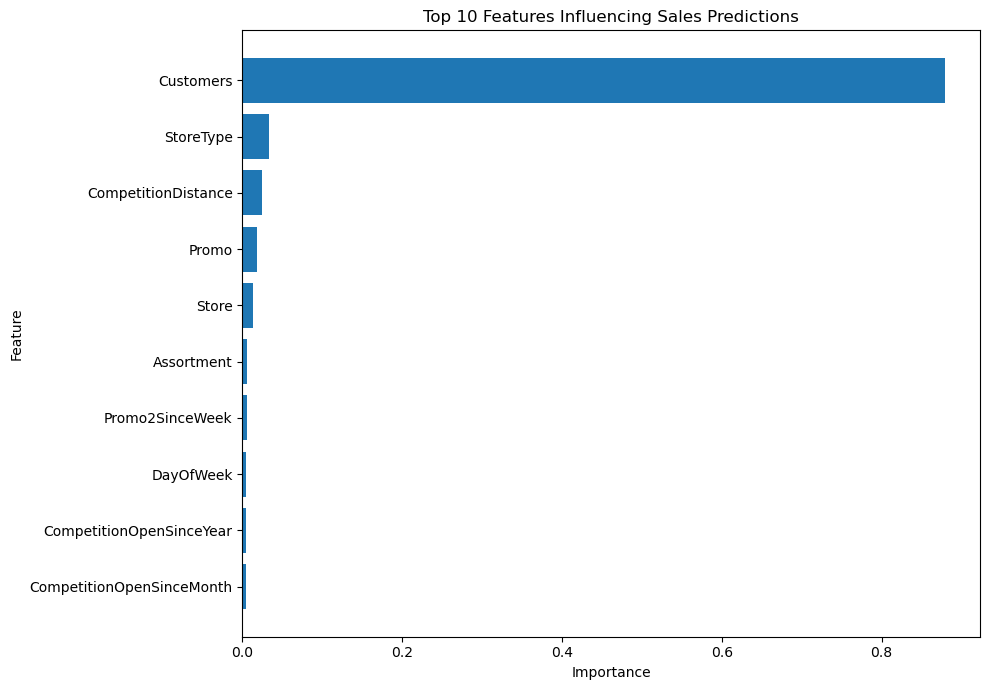

In [18]:
# ============================================================
# 15. FEATURE IMPORTANCE VISUALIZATION
# ============================================================

plt.figure(figsize=(10, 7))

plt.barh(
    feature_importance["Feature"].head(10)[::-1],
    feature_importance["Importance"].head(10)[::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Features Influencing Sales Predictions")

plt.tight_layout()
plt.show()

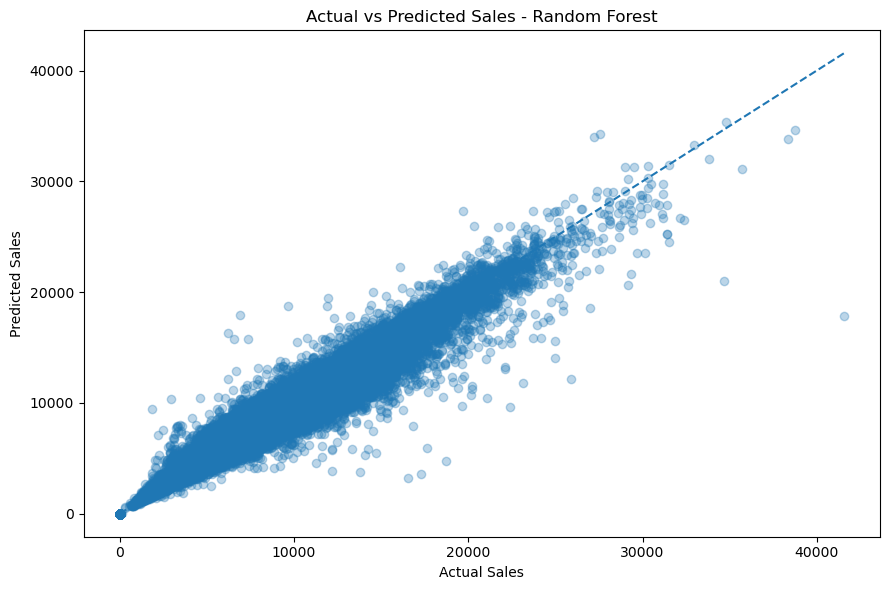

In [19]:
# ============================================================
# 16. ACTUAL VS PREDICTED SALES
# ============================================================

plt.figure(figsize=(9, 6))

plt.scatter(
    y_test,
    y_pred_rf,
    alpha=0.3
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales - Random Forest")

# Perfect prediction reference line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.tight_layout()
plt.show()

In [20]:
# ============================================================
# 17. SAVE BEST MODEL
# ============================================================

MODEL_PATH = r"C:\Users\ANTARA\OneDrive\Documents\Career\Dynamic Pricing Intelligence System\best_pricing_model.pkl"

joblib.dump(
    random_forest,
    MODEL_PATH
)

print("✅ Best Random Forest model saved successfully!")
print("Model path:", MODEL_PATH)

✅ Best Random Forest model saved successfully!
Model path: C:\Users\ANTARA\OneDrive\Documents\Career\Dynamic Pricing Intelligence System\best_pricing_model.pkl


In [21]:
# ============================================================
# 18. SAVE MODEL FEATURE ORDER
# ============================================================

FEATURES_PATH = r"C:\Users\ANTARA\OneDrive\Documents\Career\Dynamic Pricing Intelligence System\model_features.pkl"

model_features = list(X.columns)

joblib.dump(
    model_features,
    FEATURES_PATH
)

print("✅ Model feature order saved successfully!")
print()
print("Number of features:", len(model_features))
print()
print("Feature order:")
for i, feature in enumerate(model_features, start=1):
    print(f"{i}. {feature}")

✅ Model feature order saved successfully!

Number of features: 16

Feature order:
1. Store
2. DayOfWeek
3. Customers
4. Open
5. Promo
6. StateHoliday
7. SchoolHoliday
8. StoreType
9. Assortment
10. CompetitionDistance
11. CompetitionOpenSinceMonth
12. CompetitionOpenSinceYear
13. Promo2
14. Promo2SinceWeek
15. Promo2SinceYear
16. PromoInterval


In [23]:
# ============================================================
# 19. VERIFY SAVED MODEL FILES
# ============================================================

import os

print("Checking saved model files...")
print()

print(
    "Model file exists:",
    os.path.exists(MODEL_PATH)
)

print(
    "Feature file exists:",
    os.path.exists(FEATURES_PATH)
)

print()

if os.path.exists(MODEL_PATH):
    model_size = os.path.getsize(MODEL_PATH) / (1024 * 1024)
    print(f"Model file size: {model_size:.2f} MB")

if os.path.exists(FEATURES_PATH):
    feature_size = os.path.getsize(FEATURES_PATH) / 1024
    print(f"Feature file size: {feature_size:.2f} KB")

Checking saved model files...

Model file exists: True
Feature file exists: True

Model file size: 181.38 MB
Feature file size: 0.25 KB


In [24]:
# ============================================================
# 20. TEST RANDOM FOREST PREDICTION
# ============================================================

test_sample = X_test.head(5)

test_predictions = random_forest.predict(test_sample)

print("✅ Random Forest prediction test successful!")
print()

for i, prediction in enumerate(test_predictions, start=1):
    print(f"Sample {i}: Predicted Sales = {prediction:.2f}")

✅ Random Forest prediction test successful!

Sample 1: Predicted Sales = 0.00
Sample 2: Predicted Sales = 6594.52
Sample 3: Predicted Sales = 7873.73
Sample 4: Predicted Sales = 3639.72
Sample 5: Predicted Sales = 9905.06


In [25]:
# ============================================================
# 21. CHECK CATEGORICAL FEATURE VALUES
# ============================================================

categorical_features = [
    "StateHoliday",
    "StoreType",
    "Assortment",
    "PromoInterval"
]

for feature in categorical_features:
    print(f"\n{feature}:")
    print(sorted(pricing_df[feature].unique()))


StateHoliday:
[np.int64(0), np.int64(1), np.int64(2), np.int64(3)]

StoreType:
[np.int64(0), np.int64(1), np.int64(2), np.int64(3)]

Assortment:
[np.int64(0), np.int64(1), np.int64(2)]

PromoInterval:
[np.int64(0), np.int64(1), np.int64(2), np.int64(3)]


In [28]:
# ============================================================
# 22. CHECK EXISTING DATAFRAME COLUMNS
# ============================================================

print("Dataframes currently available:")

for name, obj in globals().items():
    if isinstance(obj, pd.DataFrame):
        print(f"- {name}: {obj.shape}")

Dataframes currently available:
- pricing_df: (1017209, 18)
- X: (1017209, 16)
- X_train: (813767, 16)
- X_test: (203442, 16)
- X_rf: (200000, 16)
- model_comparison: (3, 4)
- feature_importance: (16, 2)
- test_sample: (5, 16)


In [29]:
# ============================================================
# 22. INSPECT ENCODED CATEGORIES
# ============================================================

print("Sample values from categorical columns:\n")

display(
    pricing_df[
        ["StateHoliday", "StoreType", "Assortment", "PromoInterval"]
    ].head(20)
)

Sample values from categorical columns:



,StateHoliday,StoreType,Assortment,PromoInterval
0,0,2,0,3
1,0,0,0,1
2,0,0,0,1
3,0,2,2,3
4,0,0,0,3
5,0,0,0,3
6,0,0,2,3
7,0,0,0,3
8,0,0,2,3
9,0,0,0,3


In [32]:
# ============================================================
# 23. FINAL MODEL EVALUATION SUMMARY
# ============================================================

final_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "MAE": [
        mae_linear,
        mae_tree,
        mae_rf
    ],
    "RMSE": [
        rmse_linear,
        rmse_tree,
        rmse_rf
    ],
    "R2 Score": [
        r2_linear,
        r2_tree,
        r2_rf
    ]
})

final_results = final_results.sort_values(
    by="R2 Score",
    ascending=False
).reset_index(drop=True)

display(final_results)

,Model,MAE,RMSE,R2 Score
0,Random Forest,404.954318,650.880219,0.971354
1,Decision Tree,444.656217,717.905859,0.965150
2,Linear Regression,948.777099,1407.858507,0.865975


In [33]:
# ============================================================
# 24. SAVE FINAL MODEL INFORMATION
# ============================================================

final_model_info = {
    "model_name": "Random Forest Regressor",
    "mae": mae_rf,
    "rmse": rmse_rf,
    "r2_score": r2_rf,
    "n_estimators": 100,
    "max_depth": 15,
    "training_samples": len(X_rf),
    "features": model_features
}

INFO_PATH = r"C:\Users\ANTARA\OneDrive\Documents\Career\Dynamic Pricing Intelligence System\final_model_info.pkl"

joblib.dump(
    final_model_info,
    INFO_PATH
)

print("✅ Final model information saved successfully!")
print("Path:", INFO_PATH)

✅ Final model information saved successfully!
Path: C:\Users\ANTARA\OneDrive\Documents\Career\Dynamic Pricing Intelligence System\final_model_info.pkl


In [34]:
# ============================================================
# 25. FINAL PREDICTION TEST
# ============================================================

sample_row = X_test.iloc[[0]]

actual_sales = y_test.iloc[0]

predicted_sales = random_forest.predict(sample_row)[0]

print("✅ Final prediction test completed!")
print()
print("Actual Sales   :", actual_sales)
print("Predicted Sales:", round(predicted_sales, 2))
print("Prediction Error:", round(actual_sales - predicted_sales, 2))

✅ Final prediction test completed!

Actual Sales   : 0
Predicted Sales: 0.0
Prediction Error: 0.0


In [36]:
# ============================================================
# 26. TEST PREDICTION ON A NON-ZERO SALES ROW
# ============================================================

non_zero_index = y_test[y_test > 0].index[0]

sample_row = X_test.loc[[non_zero_index]]

actual_sales = y_test.loc[non_zero_index]

predicted_sales = random_forest.predict(sample_row)[0]

print("✅ Non-zero sales prediction test completed!")
print()
print("Actual Sales    :", actual_sales)
print("Predicted Sales :", round(predicted_sales, 2))
print("Prediction Error:", round(actual_sales - predicted_sales, 2))

✅ Non-zero sales prediction test completed!

Actual Sales    : 5548
Predicted Sales : 6594.52
Prediction Error: -1046.52


In [37]:
# ============================================================
# 27. SAVE FEATURE SCALER
# ============================================================

SCALER_PATH = r"C:\Users\ANTARA\OneDrive\Documents\Career\Dynamic Pricing Intelligence System\feature_scaler.pkl"

joblib.dump(
    scaler,
    SCALER_PATH
)

print("✅ Feature scaler saved successfully!")
print("Path:", SCALER_PATH)

✅ Feature scaler saved successfully!
Path: C:\Users\ANTARA\OneDrive\Documents\Career\Dynamic Pricing Intelligence System\feature_scaler.pkl


In [41]:
# ============================================================
# 28. FINAL ML PERFORMANCE TABLE - FIXED
# ============================================================

# ---------- Linear Regression ----------
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)

# ---------- Decision Tree ----------
y_pred_dt = decision_tree.predict(X_test)

# ---------- Random Forest ----------
y_pred_rf = random_forest.predict(X_test)

# ---------- Calculate Metrics ----------
model_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "MAE": [
        mean_absolute_error(y_test, y_pred_lr),
        mean_absolute_error(y_test, y_pred_dt),
        mean_absolute_error(y_test, y_pred_rf)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, y_pred_lr)),
        np.sqrt(mean_squared_error(y_test, y_pred_dt)),
        np.sqrt(mean_squared_error(y_test, y_pred_rf))
    ],
    "R2": [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_dt),
        r2_score(y_test, y_pred_rf)
    ]
})

display(model_results.round(4))

,Model,MAE,RMSE,R2
0,Linear Regression,948.7771,1407.8585,0.8660
1,Decision Tree,444.6562,717.9059,0.9652
2,Random Forest,404.9543,650.8802,0.9714


In [42]:
# ============================================================
# 29. FINAL SALES PREDICTION FUNCTION
# ============================================================

def predict_sales(input_data):
    """
    Predict sales using the trained Random Forest model.
    """

    input_df = pd.DataFrame(input_data)

    # Keep features in the same order used during training
    input_df = input_df[model_features]

    # Predict sales
    prediction = random_forest.predict(input_df)

    return prediction


print("✅ Prediction function created successfully!")

✅ Prediction function created successfully!


In [43]:
# ============================================================
# 30. FINAL ML PIPELINE SUMMARY
# ============================================================

print("=" * 60)
print("       DYNAMIC PRICING INTELLIGENCE SYSTEM")
print("              MACHINE LEARNING SUMMARY")
print("=" * 60)

print("\n📌 Problem:")
print("Predict store sales using historical business data.")

print("\n📌 Dataset:")
print(f"Total records: {len(pricing_df):,}")
print(f"Total features used: {len(model_features)}")

print("\n📌 Models Evaluated:")
print("1. Linear Regression")
print("2. Decision Tree Regressor")
print("3. Random Forest Regressor")

print("\n📌 Best Model:")
print("Random Forest Regressor")

print("\n📊 Final Performance:")
print(f"MAE  : {mean_absolute_error(y_test, y_pred_rf):.2f}")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred_rf)):.2f}")
print(f"R²   : {r2_score(y_test, y_pred_rf):.4f}")

print("\n📌 Training Configuration:")
print("Trees:", 100)
print("Maximum Depth:", 15)
print("Training Samples:", len(X_rf))

print("\n📌 Most Important Feature:")
print(feature_importance.iloc[0]["Feature"])

print("\n📁 Saved Model:")
print(MODEL_PATH)

print("=" * 60)
print("✅ MACHINE LEARNING PIPELINE COMPLETED")
print("=" * 60)

       DYNAMIC PRICING INTELLIGENCE SYSTEM
              MACHINE LEARNING SUMMARY

📌 Problem:
Predict store sales using historical business data.

📌 Dataset:
Total records: 1,017,209
Total features used: 16

📌 Models Evaluated:
1. Linear Regression
2. Decision Tree Regressor
3. Random Forest Regressor

📌 Best Model:
Random Forest Regressor

📊 Final Performance:
MAE  : 404.95
RMSE : 650.88
R²   : 0.9714

📌 Training Configuration:
Trees: 100
Maximum Depth: 15
Training Samples: 200000

📌 Most Important Feature:
Customers

📁 Saved Model:
C:\Users\ANTARA\OneDrive\Documents\Career\Dynamic Pricing Intelligence System\best_pricing_model.pkl
✅ MACHINE LEARNING PIPELINE COMPLETED
